# Lab 7: The Attention Mechanism

---

## Why Attention? — The Problem We Are Trying to Solve

Suppose you are reading the sentence:

> *"The animal didn't cross the street because **it** was too tired."*

What does **it** refer to? *The animal*, of course — not *the street*. You know
this because you mentally linked the pronoun back to the most relevant noun in the sentence.

This is exactly the kind of reasoning a language model needs. Every word in a
sentence may depend on *any* other word, regardless of distance.

**The challenge:** Neural networks process vectors, not words. How do we build a
computation that dynamically says *"this word's representation should be mostly influenced by that word over there"*?

### What We Had Before: Fixed Windows

Earlier deep learning approaches used **fixed local windows**: a token at position $t$
is only allowed to look at the $k$ tokens immediately preceding it. This is fast and
simple, but fails as soon as a relevant dependency is more than $k$ steps away.

**RNNs** avoid the fixed window by maintaining a *hidden state* that is passed forward.
But the hidden state becomes a bottleneck: information about position 1 must survive
through hundreds of hidden-state updates to influence position 500. In practice, RNNs
forget distant context.

### The Attention Idea: Dynamic, Learned Weighting

The key insight of attention (Bahdanau et al., 2015; Vaswani et al., 2017) is:

> **Every token is allowed to look at every other token, but it decides for itself
how much to weight each one.**

The weighting is learned from data, not fixed. After training, the model might learn
that pronouns should attend strongly to nouns, that `[MASK]` tokens should attend to
surrounding context, etc.

---

## Road Map

| Exercise | Topic | What we build |
|----------|-------|---------------|
| 1 | Similarity & Weighted Averages | Dot product, softmax, weighted sum |
| 2 | Scaled Dot-Product Attention | Full attention formula, step by step |
| 3 | Causal (Masked) Attention | The autoregressive constraint, masking |
| 4 | Self-Attention on a Sequence | Projections $W^Q, W^K, W^V$; attention over real text |
| 5 | `SelfAttention` Module | PyTorch `nn.Module`, weight visualisation |
| 6 | Multi-Head Attention | Why multiple heads, splitting & merging, `MultiHeadAttention` module |

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import math

torch.manual_seed(42)

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})


---
## Exercise 1: Similarity and Weighted Averages

Let's build the three mathematical primitives
attention is made of:

1. **Dot-product similarity** — how *similar* are two vectors?
2. **Softmax** — how do we turn raw similarity scores into a proper probability distribution?
3. **Weighted average** — how do we combine multiple vectors according to those probabilities?

These three steps are, literally, scaled dot-product attention (minus the projections).

---
### Exercise 1.1 — Dot-product similarity

Given two vectors $\mathbf{a}, \mathbf{b} \in \mathbb{R}^d$, their **dot product** is:

$$\mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^{d} a_i b_i$$

This is the standard measure of similarity used in attention. Two vectors pointing in the
same direction in $\mathbb{R}^d$ have a large positive dot product; orthogonal vectors
have a dot product of 0; opposite-direction vectors have a negative dot product.

**Your task:** Given one **query** vector $\mathbf{q} \in \mathbb{R}^d$ and a matrix of
**keys** $K \in \mathbb{R}^{n \times d}$ (one key per row), compute the vector of raw
similarity scores $\mathbf{s} \in \mathbb{R}^n$ where $s_i = \mathbf{q} \cdot K_i$.

**Hint:** This is a matrix-vector product. In PyTorch: `K @ q` (or equivalently `q @ K.T`).


In [ ]:
def dot_product_scores(q: torch.Tensor, K: torch.Tensor) -> torch.Tensor:
    """
    Compute raw similarity scores between a query and all keys.

    Parameters
    ----------
    q : (d,)       — the query vector
    K : (n, d)     — n key vectors stacked as rows

    Returns
    -------
    s : (n,)       — score s[i] = q · K[i]
    """
    # YOUR CODE HERE
    raise NotImplementedError


# ── Quick test ────────────────────────────────────────────────────────────────
d = 4
q_ex = torch.tensor([1.0, 0.0, 0.0, 0.0])          # points in direction e_1
K_ex = torch.tensor([
    [ 1.0, 0.0, 0.0, 0.0],   # identical to q  → score = 1.0
    [ 0.0, 1.0, 0.0, 0.0],   # orthogonal      → score = 0.0
    [-1.0, 0.0, 0.0, 0.0],   # opposite        → score = -1.0
    [ 0.5, 0.5, 0.0, 0.0],   # partial overlap → score = 0.5
])

s = dot_product_scores(q_ex, K_ex)
print("Scores:", s)
# Expected: tensor([ 1.0,  0.0, -1.0,  0.5])


### Exercise 1.2 — Softmax

We have raw scores $\mathbf{s} \in \mathbb{R}^n$. We want to convert them to **attention weights** — a probability distribution that sums to 1 and is non-negative.

The **softmax** function does this:

$$\text{softmax}(\mathbf{s})_i = \frac{e^{s_i}}{\sum_{j=1}^{n} e^{s_j}}$$

**Properties:**
- All outputs are in $(0, 1)$ (strictly positive — every position gets at least a tiny weight).
- Outputs sum to 1.
- The largest score gets the highest weight (*winner takes more*, but not all).
- The function is differentiable — crucial for backpropagation.

**Numerical stability:** Computing $e^{s_i}$ directly can overflow when $s_i$ is large. In practice, we subtract the maximum first:

$$\text{softmax}(\mathbf{s})_i = \frac{e^{s_i - \max_j s_j}}{\sum_{j=1}^{n} e^{s_j - \max_j s_j}}$$

This is numerically identical (the max cancels in numerator and denominator) but never overflows.

In [ ]:
def softmax(s: torch.Tensor) -> torch.Tensor:
    """
    Softmax along the last axis.

    Parameters
    ----------
    s : (..., n)  — raw scores

    Returns
    -------
    w : (..., n)  — attention weights (sum to 1 along last axis)
    """
    # YOUR CODE HERE
    raise NotImplementedError


# ── Test on our example scores ────────────────────────────────────────────────
w = softmax(s)
print("Attention weights:", w)
print("Sum of weights   :", w.sum().item())   # must be 1.0

# ── Visualise ─────────────────────────────────────────────────────────────────
labels = ['key 0\n(identical)', 'key 1\n(orthogonal)', 'key 2\n(opposite)', 'key 3\n(partial)']
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].bar(labels, s.tolist())
ax[0].set_title('Raw scores')
ax[0].set_ylabel('score')
ax[1].bar(labels, w.tolist(), color='orange')
ax[1].set_title('After softmax (attention weights)')
ax[1].set_ylabel('weight')
ax[1].set_ylim(0, 1)
for i, (si, wi) in enumerate(zip(s.tolist(), w.tolist())):
    ax[0].text(i, si + 0.02, f'{si:.2f}', ha='center', fontsize=9)
    ax[1].text(i, wi + 0.01, f'{wi:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


**Observation:** The key that is *identical* to the query gets the most weight (~0.576), the *partial overlap* key gets the second most, and the *opposite* key gets almost nothing. The *orthogonal* key sits in between.

Notice that even `key 2` (score = -1.0) gets a small but non-zero weight (≈ 0.064). Softmax is never exactly 0 — attention is always *soft*, never hard.

### Exercise 1.3 — Weighted average of Values

Now we have attention weights $\mathbf{w} \in \mathbb{R}^n$ (summing to 1). We also have a matrix of **values** $V \in \mathbb{R}^{n \times d_v}$ — one value vector per key position.

The **attention output** for query $\mathbf{q}$ is the weighted average of all values:

$$\mathbf{o} = \sum_{i=1}^{n} w_i \, \mathbf{v}_i = V^\top \mathbf{w}$$

In matrix notation (with $V$ having rows $\mathbf{v}_i$): $\mathbf{o} = V^\top \mathbf{w}$, which in PyTorch is `V.T @ w` or equivalently `w @ V`.

**Intuition:** The output $\mathbf{o}$ is a *blend* of all value vectors. If query $\mathbf{q}$ is very similar to key $\mathbf{k}_3$, then $w_3 \approx 1$ and the output is approximately $\mathbf{v}_3$. If the query is similar to two keys equally, the output is the average of their values.

In [ ]:
def weighted_average(w: torch.Tensor, V: torch.Tensor) -> torch.Tensor:
    """
    Compute the weighted average of value vectors.

    Parameters
    ----------
    w : (n,)       — attention weights (should sum to 1)
    V : (n, d_v)   — value matrix (one value vector per row)

    Returns
    -------
    o : (d_v,)     — the weighted sum of value vectors
    """
    # YOUR CODE HERE
    raise NotImplementedError


# ── Test ──────────────────────────────────────────────────────────────────────
# Values: each row represents the 'content' of that position.
# We use simple 2-D vectors so we can visualise.
V_ex = torch.tensor([
    [ 1.0, 0.0],    # value for key 0 (identical to query)
    [ 0.0, 1.0],    # value for key 1 (orthogonal)
    [-1.0, 0.0],    # value for key 2 (opposite)
    [ 0.5, 0.5],    # value for key 3 (partial overlap)
])

o = weighted_average(w, V_ex)
print("Attention output:", o)
print("(Mostly a blend of value 0 and value 3, since they have the highest weights)")

# ── Corner case: uniform weights → output is the simple mean of all values ────
w_uniform = torch.ones(4) / 4
o_uniform = weighted_average(w_uniform, V_ex)
print("\nWith uniform weights:", o_uniform, "== mean of rows:", V_ex.mean(dim=0))


---
## Exercise 2: Scaled Dot-Product Attention

We now combine Exercises 1.1–1.3 into the complete attention formula, and add one important ingredient: the **scaling factor** $\sqrt{d_k}$.

The full formula for **one query** attending to $n$ key-value pairs is:

$$\mathbf{o} = \text{Attention}(\mathbf{q}, K, V)
= \underbrace{\text{softmax}\!\left(\frac{\mathbf{q} K^\top}{\sqrt{d_k}}\right)}_{\text{attention weights } \mathbf{w}} V$$

**Steps:**
1. Compute raw scores: $\mathbf{s} = \mathbf{q} K^\top / \sqrt{d_k}$
2. Apply softmax: $\mathbf{w} = \text{softmax}(\mathbf{s})$
3. Weighted average: $\mathbf{o} = \mathbf{w} V$

---
### Exercise 2.1 — Why do we divide by $\sqrt{d_k}$?

Consider two random vectors $\mathbf{q}, \mathbf{k} \in \mathbb{R}^{d_k}$ where each component is independently drawn from $\mathcal{N}(0, 1)$. Their dot product is:

$$\mathbf{q} \cdot \mathbf{k} = \sum_{i=1}^{d_k} q_i k_i$$

Since $q_i k_i$ has mean 0 and variance 1,

$$\mathbb{E}[\mathbf{q} \cdot \mathbf{k}] = 0, \qquad \text{Var}[\mathbf{q} \cdot \mathbf{k}] = d_k$$

So the standard deviation of the raw dot product grows as $\sqrt{d_k}$. For large $d_k$ (e.g., 64), the scores are spread over a much wider range, which pushes the softmax into its **saturating regime**: one score is much larger than all others, the distribution approaches a one-hot vector, and **gradients vanish** (the softmax Jacobian goes to zero).

Dividing by $\sqrt{d_k}$ brings the variance back to 1 regardless of $d_k$.

The cell below demonstrates this effect:

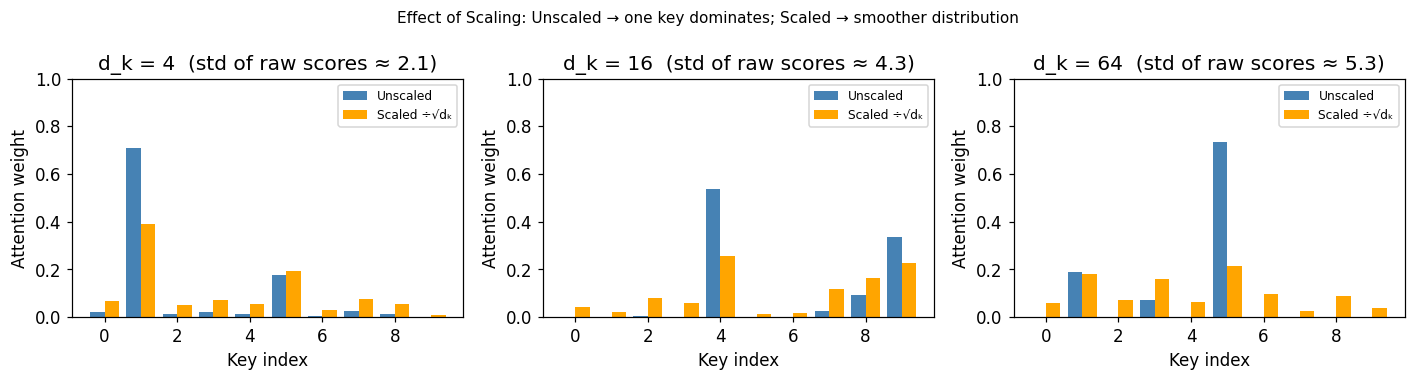

In [5]:
# ── Demonstrate the scaling effect ──────────────────────────────────────────
torch.manual_seed(0)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

for ax, d_k in zip(axes, [4, 16, 64]):
    q_demo = torch.randn(d_k)
    K_demo = torch.randn(10, d_k)   # 10 keys

    raw_scores    = K_demo @ q_demo
    scaled_scores = raw_scores / math.sqrt(d_k)

    w_raw    = softmax(raw_scores)
    w_scaled = softmax(scaled_scores)

    x = list(range(10))
    ax.bar([xi - 0.2 for xi in x], w_raw.tolist(),    width=0.4, label='Unscaled',    color='steelblue')
    ax.bar([xi + 0.2 for xi in x], w_scaled.tolist(), width=0.4, label='Scaled ÷√dₖ', color='orange')
    ax.set_title(f'd_k = {d_k}  (std of raw scores ≈ {raw_scores.std().item():.1f})')
    ax.set_xlabel('Key index')
    ax.set_ylabel('Attention weight')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.suptitle('Effect of Scaling: Unscaled → one key dominates; Scaled → smoother distribution',
             fontsize=10)
plt.tight_layout()
plt.show()


**Key observation:** For large $d_k$ (right panel), the unscaled weights become
nearly one-hot — one key gets almost all the weight. After scaling by $\sqrt{d_k}$,
the distribution is smoother and more informative. Smooth distributions have
**better gradient flow** during training.

---
### Exercise 2.2 — Implement single-query attention

Implement:

```python
attention_single(
    q: torch.Tensor,   # (d_k,)
    K: torch.Tensor,   # (n, d_k)
    V: torch.Tensor,   # (n, d_v)
) -> tuple[torch.Tensor, torch.Tensor]
```

Return `(output, weights)` where:
- `output` has shape `(d_v,)` — the blended value vector
- `weights` has shape `(n,)` — the attention probabilities


In [ ]:
def attention_single(
    q: torch.Tensor,
    K: torch.Tensor,
    V: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Scaled dot-product attention for a single query.

    Parameters
    ----------
    q : (d_k,)    — query vector
    K : (n, d_k)  — key matrix
    V : (n, d_v)  — value matrix

    Returns
    -------
    output  : (d_v,)  — weighted average of value vectors
    weights : (n,)    — attention weights (sum to 1)
    """
    # YOUR CODE HERE
    raise NotImplementedError


# ── Test ──────────────────────────────────────────────────────────────────────
torch.manual_seed(0)
d_k, d_v, n = 8, 8, 5

q_test = torch.randn(d_k)
K_test = torch.randn(n, d_k)
V_test = torch.randn(n, d_v)

out, wts = attention_single(q_test, K_test, V_test)
print("Output shape :", out.shape)                      # torch.Size([8])
print("Weights shape:", wts.shape)                      # torch.Size([5])
print("Weights sum  :", round(wts.sum().item(), 6))     # 1.0
print("Weights      :", wts)


### Exercise 2.3 — Multi-query attention (all queries at once)

In practice, we don't compute attention for one query at a time — we compute it
for **all $n$ queries simultaneously**. This is dramatically more efficient because
matrix multiplications are highly parallelised on modern hardware.

Given $Q \in \mathbb{R}^{n \times d_k}$ (all queries stacked row by row), the full
attention is:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V$$

where:
- $QK^\top \in \mathbb{R}^{n \times n}$ — entry $(i, j)$ is the similarity between query $i$ and key $j$
- $\text{softmax}(\cdot)$ applied **row-wise** — each row sums to 1
- The result $A \in \mathbb{R}^{n \times n}$ is the **attention matrix**
- $A V \in \mathbb{R}^{n \times d_v}$ — row $i$ is the output for position $i$

Implement:

```python
attention(
    Q: torch.Tensor,              # (n, d_k)
    K: torch.Tensor,              # (n, d_k)
    V: torch.Tensor,              # (n, d_v)
    mask: torch.Tensor | None,    # (n, n) bool, optional
) -> tuple[torch.Tensor, torch.Tensor]
```

Return `(output, A)` where:
- `output` has shape `(n, d_v)`
- `A` has shape `(n, n)` (the attention weight matrix)


In [ ]:
def attention(
    Q: torch.Tensor,
    K: torch.Tensor,
    V: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Full scaled dot-product attention.

    Parameters
    ----------
    Q    : (n, d_k)      — query matrix
    K    : (n, d_k)      — key matrix
    V    : (n, d_v)      — value matrix
    mask : (n, n) bool   — True where attention IS allowed (optional)

    Returns
    -------
    output : (n, d_v)  — attention output for each position
    A      : (n, n)    — attention weight matrix (rows sum to 1)
    """
    # YOUR CODE HERE
    raise NotImplementedError


# ── Test ──────────────────────────────────────────────────────────────────────
torch.manual_seed(1)
n, d_k, d_v = 6, 8, 8
Q_test = torch.randn(n, d_k)
K_test = torch.randn(n, d_k)
V_test = torch.randn(n, d_v)

out, A = attention(Q_test, K_test, V_test)
print("Output shape :", out.shape)   # torch.Size([6, 8])
print("Attn  shape  :", A.shape)     # torch.Size([6, 6])
print("Row sums (must all be 1):", A.sum(dim=1))

# ── Visualise the attention matrix ────────────────────────────────────────────
plt.figure(figsize=(4, 3.5))
plt.imshow(A.detach().numpy(), vmin=0, vmax=A.max().item(), cmap='Blues')
plt.colorbar(label='attention weight')
plt.xlabel('Key position $j$')
plt.ylabel('Query position $i$')
plt.title('Attention matrix A\n(bidirectional, random Q/K)')
plt.xticks(range(n))
plt.yticks(range(n))
for i in range(n):
    for j in range(n):
        plt.text(j, i, f'{A[i,j].item():.2f}', ha='center', va='center', fontsize=7)
plt.tight_layout()
plt.show()


**Reading the attention matrix:** Row $i$ tells you how much position $i$ attends to each other position $j$. Each row sums to 1. In this random example, the weights are fairly uniform — there is no meaningful structure because $Q$ and $K$ were sampled randomly. In a trained model, you would see clear patterns.

---
## Exercise 3: Causal (Masked) Attention

### Why Masking?

Imagine training a language model: given the sequence `[T, h, e, ' ', c, a, t]`, the model must predict each next character from the characters seen so far. Concretely:

| Position | Input | Must predict | May look at |
|----------|-------|--------------|-------------|
| 0 | T | h | T (only position 0) |
| 1 | h | e | T, h (positions 0–1) |
| 2 | e | (space) | T, h, e (positions 0–2) |
| 3 | (space) | c | T, h, e, space |
| ... | ... | ... | ... |

Position $i$ must **not** see positions $j > i$ (future tokens). If it did, the problem would be trivial — the model would just copy the next token.

We enforce this with a **causal mask**: a lower-triangular boolean matrix where $\text{mask}_{ij} = \text{True}$ if and only if $j \leq i$.

$$\text{mask} = \begin{pmatrix}
1 & 0 & 0 & 0 \\
1 & 1 & 0 & 0 \\
1 & 1 & 1 & 0 \\
1 & 1 & 1 & 1
\end{pmatrix}$$

Forbidden positions (0 in the mask) get a score of $-\infty$, which becomes $e^{-\infty} = 0$ after softmax — they are completely ignored.

---
### Exercise 3.1 — Build the causal mask

In [ ]:
def causal_mask(n: int) -> torch.Tensor:
    """
    Build a boolean lower-triangular causal mask of size (n, n).

    mask[i, j] = True  iff j <= i  (position i is allowed to look at position j)
    """
    # YOUR CODE HERE
    raise NotImplementedError


mask_ex = causal_mask(6)
print("Causal mask (6x6):")
print(mask_ex.int())

# ── Visualise ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(3.5, 3))
plt.imshow(mask_ex.numpy(), cmap='Greens', vmin=0, vmax=1)
plt.title('Causal Mask\n(green = allowed, white = forbidden)')
plt.xlabel('Key position $j$')
plt.ylabel('Query position $i$')
plt.xticks(range(6))
plt.yticks(range(6))
plt.tight_layout()
plt.show()


### Exercise 3.2 — Compare attention with and without the mask

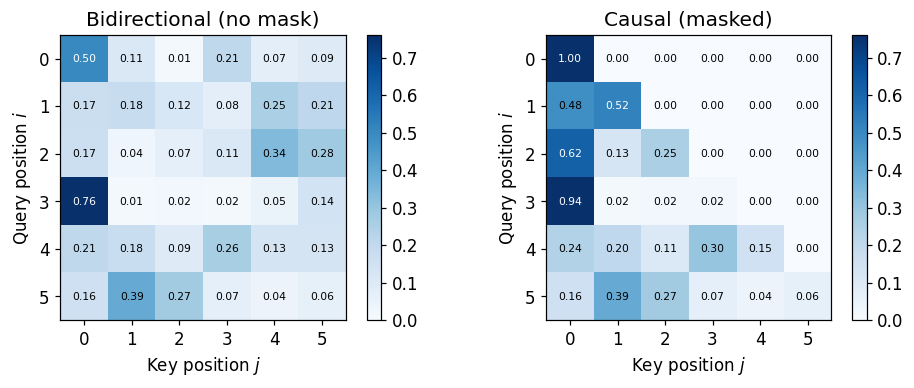

Upper-triangle values in causal A (should all be 0): tensor([0.])


In [9]:
torch.manual_seed(3)
n = 6
Q_c = torch.randn(n, 8)
K_c = torch.randn(n, 8)
V_c = torch.randn(n, 8)
mask_c = causal_mask(n)

out_bidir,  A_bidir  = attention(Q_c, K_c, V_c)                   # no mask
out_causal, A_causal = attention(Q_c, K_c, V_c, mask=mask_c)      # with mask

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, A, title in [
    (axes[0], A_bidir,  'Bidirectional (no mask)'),
    (axes[1], A_causal, 'Causal (masked)'),
]:
    A_np = A.detach().numpy()
    im = ax.imshow(A_np, vmin=0, vmax=A_bidir.max().item(), cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Key position $j$')
    ax.set_ylabel('Query position $i$')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    for i in range(n):
        for j in range(n):
            v = A[i, j].item()
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=7, color='black' if v < 0.5 else 'white')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# Verify: upper triangle of causal attention should be exactly 0
rows, cols = torch.triu_indices(n, n, offset=1)
upper = A_causal[rows, cols]
print(f"Upper-triangle values in causal A (should all be 0): {upper.unique()}")


**Key check:** In the causal attention matrix (right panel), all entries *above* the diagonal are exactly 0. Position $i$ cannot see any position $j > i$.

---
## Exercise 4: Self-Attention on a Real Sequence

So far, $Q$, $K$, and $V$ have been given to us directly. In a real Transformer, they are all **derived from the same input sequence** $X \in \mathbb{R}^{n \times d}$ through three learned linear projections:

$$Q = X W^Q, \qquad K = X W^K, \qquad V = X W^V$$

where $W^Q, W^K \in \mathbb{R}^{d \times d_k}$ and $W^V \in \mathbb{R}^{d \times d_v}$ are learned weight matrices.

The word **self**-attention means the sequence attends to *itself*: the queries, keys, and values all come from the same input $X$.

**Why separate projections?**

If we used $Q = K = V = X$ directly, every token would attend most to itself (since $\mathbf{x}_i \cdot \mathbf{x}_i = \|\mathbf{x}_i\|^2$ is typically the largest dot product). The model would have very limited expressive power — it could only compute weighted averages of the inputs themselves, with uniform-ish weights.

By learning $W^Q, W^K, W^V$, the model learns to ask useful questions (queries), advertise relevant information (keys), and carry the content that should actually be aggregated (values). These three roles are independent and can be specialised during training.

---
### Exercise 4.1 — Build input embeddings for a sentence

We will work with the short sentence `"the cat sat"`. Each character is mapped to a random vector of dimension $d = 16$. In a real model, these embeddings would be learned; here we just initialise them randomly.

In [10]:
# ── Toy corpus ────────────────────────────────────────────────────────────────
sentence = "the cat sat"
tokens   = list(sentence)   # character-level tokenisation
n_toks   = len(tokens)
d        = 16               # embedding dimension

# Build a small vocabulary of all unique characters
vocab     = sorted(set(tokens))
char2id   = {c: i for i, c in enumerate(vocab)}
n_vocab   = len(vocab)

# Embedding table (nn.Embedding handles the look-up table)
torch.manual_seed(7)
embedding_table = nn.Embedding(n_vocab, d)
nn.init.normal_(embedding_table.weight, std=0.1)

# Look up embeddings for each token in the sentence
token_ids = torch.tensor([char2id[c] for c in tokens])   # (n_toks,)
X = embedding_table(token_ids)                            # (n_toks, d)

print(f"Sentence  : {sentence!r}")
print(f"Tokens    : {tokens}")
print(f"n_toks={n_toks}, d={d}")
print(f"X shape   : {X.shape}  — {n_toks} tokens, each a {d}-dimensional vector")


Sentence  : 'the cat sat'
Tokens    : ['t', 'h', 'e', ' ', 'c', 'a', 't', ' ', 's', 'a', 't']
n_toks=11, d=16
X shape   : torch.Size([11, 16])  — 11 tokens, each a 16-dimensional vector


### Exercise 4.2 — Implement self-attention with learned projections

Implement:

```python
self_attention_pt(
    X:   torch.Tensor,           # (n, d)    — input sequence
    W_Q: torch.Tensor,           # (d, d_k)  — query projection
    W_K: torch.Tensor,           # (d, d_k)  — key projection
    W_V: torch.Tensor,           # (d, d_v)  — value projection
    mask: torch.Tensor | None    # causal mask (n, n), optional
) -> tuple[torch.Tensor, torch.Tensor]
```

**Step-by-step:**
1. Compute `Q = X @ W_Q`
2. Compute `K = X @ W_K`
3. Compute `V = X @ W_V`
4. Call `attention(Q, K, V, mask)` and return its outputs.


In [ ]:
def self_attention_pt(
    X:    torch.Tensor,
    W_Q:  torch.Tensor,
    W_K:  torch.Tensor,
    W_V:  torch.Tensor,
    mask: torch.Tensor | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Self-attention with learned projections.

    Parameters
    ----------
    X   : (n, d)    — input embeddings
    W_Q : (d, d_k)  — query weight matrix
    W_K : (d, d_k)  — key weight matrix
    W_V : (d, d_v)  — value weight matrix
    mask: (n, n)    — boolean mask (True = allowed position)

    Returns
    -------
    output : (n, d_v)  — contextualised token representations
    A      : (n, n)    — attention weight matrix
    """
    # YOUR CODE HERE
    raise NotImplementedError


# ── Test ──────────────────────────────────────────────────────────────────────
torch.manual_seed(42)
d_k_sa = d_v_sa = 8

W_Q_sa = torch.randn(d, d_k_sa) * math.sqrt(2 / d)
W_K_sa = torch.randn(d, d_k_sa) * math.sqrt(2 / d)
W_V_sa = torch.randn(d, d_v_sa) * math.sqrt(2 / d)

mask_sa = causal_mask(n_toks)
X_det   = X.detach()   # detach from embedding graph for this functional demo
out_sa, A_sa = self_attention_pt(X_det, W_Q_sa, W_K_sa, W_V_sa, mask=mask_sa)

print(f"Input  X  : {X.shape}")
print(f"Output    : {out_sa.shape}")
print(f"Attn A    : {A_sa.shape}")

# ── Visualise attention for each token ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.imshow(A_sa.detach().numpy(), cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(n_toks))
ax.set_yticks(range(n_toks))
ax.set_xticklabels([f"'{c}'" for c in tokens], fontsize=9)
ax.set_yticklabels([f"'{c}'" for c in tokens], fontsize=9)
ax.set_xlabel('Key (attends TO this token)')
ax.set_ylabel('Query (this token is attending)')
ax.set_title('Self-Attention Weights on "the cat sat" (causal)')
plt.colorbar(im, label='attention weight')
for i in range(n_toks):
    for j in range(n_toks):
        v = A_sa[i, j].item()
        if v > 0:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=7.5, color='black' if v < 0.6 else 'white')
plt.tight_layout()
plt.show()


**How to read this plot:**
- Row $i$ shows how the token at position $i$ distributes its attention across past positions.
- The first token `'t'` can only attend to itself (top-left cell = 1.0).
- The second token `'h'` distributes between itself and `'t'`.
- The last token(s) can spread attention over all previous positions.
- Entries above the diagonal are always 0 (causal mask).

---
## Exercise 5: The `SelfAttention` PyTorch Module

We now wrap self-attention into a proper `nn.Module` so it can be trained with
gradient descent. The same logic applies — we just encapsulate the weight matrices
as learnable parameters using `nn.Linear`.

**Key design choices:**

1. We use `nn.Linear(d, d_k, bias=False)` to represent $W^Q$, $W^K$, $W^V$.
   This is equivalent to right-multiplying by a weight matrix, but PyTorch `Linear`
   actually stores weights transposed (as is standard).
2. We add **dropout** on the attention weights — a regularisation technique specific
   to attention that randomly zeroes some weights during training.
3. We add a final **output projection** $W^O \in \mathbb{R}^{d_v \times d}$ to
   bring the output back to the original dimension $d$.

---
### Exercise 5.1 — Implement `SelfAttention`

Complete the PyTorch module below. The `forward` method must:

1. Compute `Q = self.W_Q(x)`, `K = self.W_K(x)`, `V = self.W_V(x)` — shape `(batch, n, d_k)`.
2. Compute raw scores `(Q @ K.transpose(-2, -1)) / sqrt(d_k)` — shape `(batch, n, n)`.
3. If a `mask` is provided, fill forbidden positions with `-inf`.
4. Apply `F.softmax(..., dim=-1)` row-wise to get attention weights `A`.
5. Apply `self.dropout(A)` (for regularisation).
6. Compute `output = A @ V` — shape `(batch, n, d_k)`.
7. Return `self.W_O(output), A`.


In [ ]:
class SelfAttention(nn.Module):
    """
    Single-head self-attention layer.

    Parameters
    ----------
    d_model  : input (and output) dimension
    d_k      : dimension of queries and keys
    d_v      : dimension of values
    dropout  : dropout probability on attention weights
    """

    def __init__(self, d_model: int, d_k: int, d_v: int, dropout: float = 0.0):
        # YOUR CODE HERE
        raise NotImplementedError

    def forward(
        self,
        x:    torch.Tensor,                   # (batch, n, d_model)
        mask: torch.Tensor | None = None,     # (1, n, n) or (batch, n, n)
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Parameters
        ----------
        x    : (batch, n, d_model)
        mask : (1, n, n)  — True where attention IS allowed

        Returns
        -------
        output : (batch, n, d_model)
        A      : (batch, n, n)  — attention weights
        """
        # YOUR CODE HERE
        raise NotImplementedError


# ── Test ──────────────────────────────────────────────────────────────────────
batch, n, d_model = 2, 11, 32
sa = SelfAttention(d_model=d_model, d_k=16, d_v=16)

x_t  = torch.randn(batch, n, d_model)
mask_t = torch.tril(torch.ones(n, n, dtype=torch.bool)).unsqueeze(0)  # (1, n, n)

out_t, A_t = sa(x_t, mask_t)
print("Output shape :", out_t.shape)    # (2, 11, 32)
print("Attn  shape  :", A_t.shape)     # (2, 11, 11)
print("Attn rows sum to 1:", A_t.sum(dim=-1).round(decimals=4))
print("Upper triangle is 0 (causal):",
      A_t[0, :, :].triu(diagonal=1).abs().max().item() == 0.0)


### Exercise 5.2 — Visualise attention weights on a real sentence

Let's build a small trained-style model and look at what attention weights it produces on a short sentence. We use the character-level vocab from `"the cat sat on the mat"` and forward-pass through one `SelfAttention` layer.

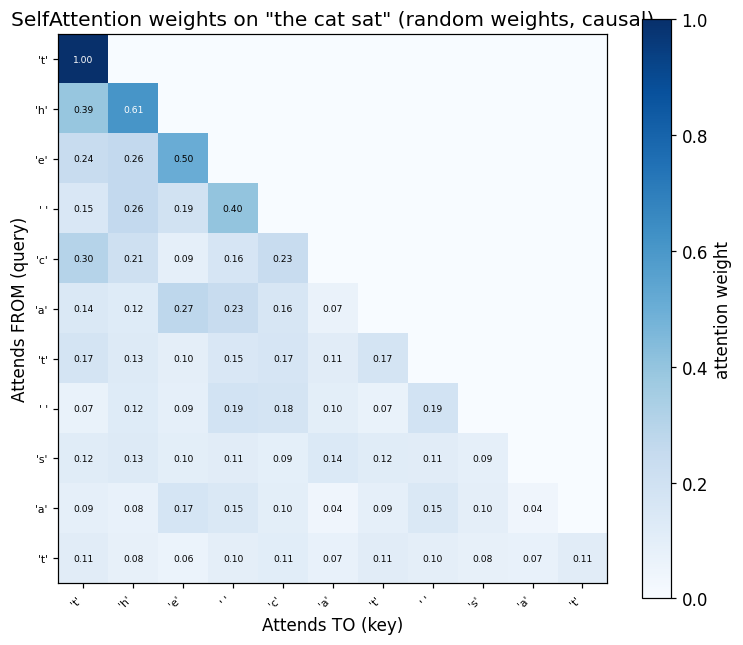

Note: with random weights the patterns are not meaningful.
After training on a large corpus, you would see structured patterns.


In [13]:
# ── Build a tiny character embedding ──────────────────────────────────────────
sentence_v = "the cat sat"
chars_v    = sorted(set(sentence_v))
c2i_v      = {c: i for i, c in enumerate(chars_v)}

D_MODEL = 32
N_V     = len(chars_v)

torch.manual_seed(0)
embed_v = nn.Embedding(N_V, D_MODEL)
sa_v    = SelfAttention(D_MODEL, d_k=16, d_v=16)

token_ids_v = torch.tensor([[c2i_v[c] for c in sentence_v]])
n_v         = token_ids_v.shape[1]
mask_v      = torch.tril(torch.ones(n_v, n_v, dtype=torch.bool)).unsqueeze(0)

with torch.no_grad():
    x_v      = embed_v(token_ids_v)       # (1, n_v, D_MODEL)
    out_v, A_v = sa_v(x_v, mask_v)       # A_v: (1, n_v, n_v)

A_np = A_v[0].numpy()   # (n_v, n_v)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(A_np, cmap='Blues', vmin=0, vmax=1)

tick_labels = [f"'{c}'" for c in sentence_v]
ax.set_xticks(range(n_v))
ax.set_yticks(range(n_v))
ax.set_xticklabels(tick_labels, fontsize=7, rotation=45, ha='right')
ax.set_yticklabels(tick_labels, fontsize=7)
ax.set_xlabel('Attends TO (key)')
ax.set_ylabel('Attends FROM (query)')
ax.set_title('SelfAttention weights on "the cat sat" (random weights, causal)')
plt.colorbar(im, label='attention weight')

for i in range(n_v):
    for j in range(n_v):
        if A_np[i, j] > 0.005:
            ax.text(j, i, f'{A_np[i,j]:.2f}', ha='center', va='center',
                    fontsize=6, color='black' if A_np[i,j] < 0.6 else 'white')

plt.tight_layout()
plt.show()

print("Note: with random weights the patterns are not meaningful.")
print("After training on a large corpus, you would see structured patterns.")

---
## Exercise 6: Multi-Head Attention

### Why Multiple Heads?

A single attention head computes one kind of relationship between tokens. But in natural language, several *independent* relationships may be important simultaneously:

- **Syntactic head 1:** subject–verb agreement (*
*)
- **Coreference head 2:** pronoun–antecedent links (*
*)
- **Positional head 3:** attending to the immediately preceding token
- **Semantic head 4:** attending to the most semantically similar past word

Of course, no one told the model which head should track which relationship — these specialisations **emerge from training** entirely through gradient descent.

### The Multi-Head Attention Formula

Run $h$ independent attention heads in **parallel**:

$$\text{head}_i = \text{Attention}(X W_i^Q,\; X W_i^K,\; X W_i^V) \in \mathbb{R}^{n \times d_v}$$

Concatenate all heads:

$$\text{MultiHead}(X) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) \, W^O$$

where $W^O \in \mathbb{R}^{h d_v \times d}$ projects back to the original dimension.

### The Dimension-Splitting Trick

In practice, we set $d_k = d_v = d / h$. This means:
- Each head works on a *smaller* subspace of dimension $d/h$.
- The total number of parameters is the same as one big head with dimension $d$.
- All heads can be computed **simultaneously** by a single batched matrix multiplication, so there is no runtime overhead.

Concretely, instead of $h$ separate $W_i^Q \in \mathbb{R}^{d \times (d/h)}$ matrices, we pack them into one big $W^Q \in \mathbb{R}^{d \times d}$ matrix and then reshape the output.

$$\underbrace{XW^Q}_{(n, d)} \xrightarrow{\text{reshape}} \underbrace{[h\text{ heads}]}_{(n, h, d/h)} \xrightarrow{\text{transpose}} (h, n, d/h)$$

---
### Exercise 6.1 — Implement `MultiHeadAttention`

The key steps beyond `SelfAttention`:

1. Project $X$ to full $d$-dimensional Q, K, V each.
2. **Split** each into $h$ heads: reshape `(batch, n, d)` → `(batch, n, h, d_k)` → `(batch, h, n, d_k)`.
3. Apply scaled dot-product attention to all heads at once (the batch dimension now includes $h$).
4. **Merge** heads: `(batch, h, n, d_k)` → `(batch, n, d)` by transposing back and flattening.
5. Apply the output projection $W^O$.

In [ ]:
class MultiHeadAttention(nn.Module):
    """
    Multi-head self-attention.

    Parameters
    ----------
    d_model : input/output dimension
    n_heads : number of attention heads
    dropout : dropout on attention weights
    """

    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.0):
        # YOUR CODE HERE
        raise NotImplementedError

    def _split_heads(self, t: torch.Tensor) -> torch.Tensor:
        """
        Split the last dimension into (n_heads, d_k) and transpose.

        (batch, n, d_model) → (batch, n_heads, n, d_k)
        """
        # YOUR CODE HERE
        raise NotImplementedError

    def _merge_heads(self, t: torch.Tensor) -> torch.Tensor:
        """
        Reverse of _split_heads.

        (batch, n_heads, n, d_k) → (batch, n, d_model)
        """
        # YOUR CODE HERE
        raise NotImplementedError

    def forward(
        self,
        x:    torch.Tensor,                   # (batch, n, d_model)
        mask: torch.Tensor | None = None,     # (1, 1, n, n) or (1, n, n)
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Parameters
        ----------
        x    : (batch, n, d_model)
        mask : (1, 1, n, n)  — True where attention IS allowed

        Returns
        -------
        output : (batch, n, d_model)
        A      : (batch, n_heads, n, n)  — per-head attention weights
        """
        # YOUR CODE HERE
        raise NotImplementedError


# ── Test ──────────────────────────────────────────────────────────────────────
batch, n, d_model, n_heads = 2, 12, 64, 4
mha = MultiHeadAttention(d_model=d_model, n_heads=n_heads)

x_m  = torch.randn(batch, n, d_model)
mask_m = torch.tril(torch.ones(n, n, dtype=torch.bool)).unsqueeze(0).unsqueeze(0)  # (1,1,n,n)

out_m, A_m = mha(x_m, mask_m)
print("Output shape       :", out_m.shape)   # (2, 12, 64)
print("Attn weights shape :", A_m.shape)     # (2, 4, 12, 12)
print("Row-sums (head 0)  :", A_m[0, 0].sum(dim=-1).round(decimals=4))
print("Upper triangle = 0 :",
      A_m[0, 0].triu(diagonal=1).abs().max().item() == 0.0)


### Exercise 6.2 — Visualise each head independently

One of the advantages of multi-head attention is interpretability: we can inspect each head's attention pattern separately and observe what each head has learned to focus on. Let's visualise all $h$ heads for our toy sentence.

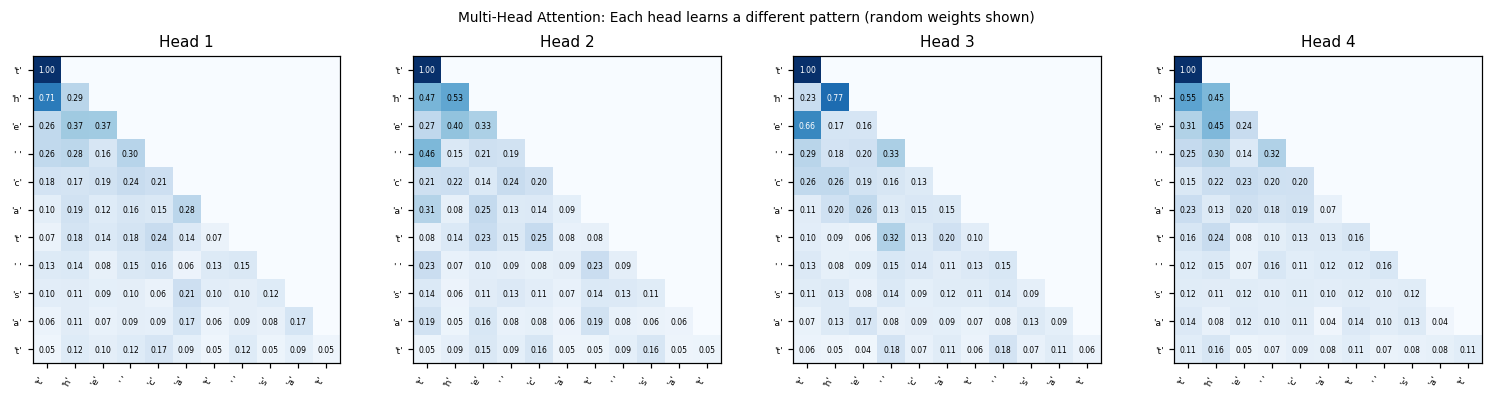

In a trained model, different heads would specialise:
  - some heads track local context (high weights near the diagonal)
  - some heads do long-range connections
  - some heads may focus on specific token types (punctuation, nouns, etc.)


In [15]:
# ── Forward pass for the visualisation sentence ───────────────────────────────
sentence_m = "the cat sat"
chars_m    = sorted(set(sentence_m))
c2i_m      = {c: i for i, c in enumerate(chars_m)}
n_m        = len(sentence_m)

torch.manual_seed(1)
D_MODEL_V  = 32
N_HEADS_V  = 4
embed_m    = nn.Embedding(len(chars_m), D_MODEL_V)
mha_v      = MultiHeadAttention(d_model=D_MODEL_V, n_heads=N_HEADS_V)

ids_m   = torch.tensor([[c2i_m[c] for c in sentence_m]])
mask_mv = torch.tril(torch.ones(n_m, n_m, dtype=torch.bool)).unsqueeze(0).unsqueeze(0)

with torch.no_grad():
    x_mv       = embed_m(ids_m)
    out_mv, A_mv = mha_v(x_mv, mask_mv)   # A_mv: (1, n_heads, n, n)

# ── Plot each head ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, N_HEADS_V, figsize=(14, 3.5))
tick_labels_m = [f"'{c}'" for c in sentence_m]

for head_idx, ax in enumerate(axes):
    A_head = A_mv[0, head_idx].numpy()   # (n, n)
    im = ax.imshow(A_head, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'Head {head_idx + 1}', fontsize=10)
    ax.set_xticks(range(n_m))
    ax.set_yticks(range(n_m))
    ax.set_xticklabels(tick_labels_m, fontsize=6, rotation=60, ha='right')
    ax.set_yticklabels(tick_labels_m, fontsize=6)
    for i in range(n_m):
        for j in range(n_m):
            if A_head[i, j] > 0.01:
                ax.text(j, i, f'{A_head[i,j]:.2f}', ha='center', va='center',
                        fontsize=5, color='black' if A_head[i,j] < 0.6 else 'white')

plt.suptitle('Multi-Head Attention: Each head learns a different pattern (random weights shown)',
             fontsize=9)
plt.tight_layout()
plt.show()

print("In a trained model, different heads would specialise:")
print("  - some heads track local context (high weights near the diagonal)")
print("  - some heads do long-range connections")
print("  - some heads may focus on specific token types (punctuation, nouns, etc.)")

### Exercise 6.3 — Count parameters

How many learnable parameters does a `MultiHeadAttention` module have?

**By hand (for $d = 64$, no bias):**
- $W^Q$: $d \times d = 64 \times 64 = 4096$
- $W^K$: $64 \times 64 = 4096$
- $W^V$: $64 \times 64 = 4096$
- $W^O$: $64 \times 64 = 4096$

**Total: $4 \times d^2 = 4 \times 4096 = 16{,}384$**

This is independent of the number of heads $h$! Adding more heads doesn't add more parameters — it just distributes the same total computation across more, smaller subspaces.

In [16]:
for h in [1, 2, 4, 8]:
    mha_h = MultiHeadAttention(d_model=64, n_heads=h)
    n_params = sum(p.numel() for p in mha_h.parameters())
    print(f"n_heads={h:2d}  →  {n_params:,} parameters  (d_k per head = {64 // h})")

print("\nConclusion: parameter count is independent of the number of heads.")

n_heads= 1  →  16,384 parameters  (d_k per head = 64)
n_heads= 2  →  16,384 parameters  (d_k per head = 32)
n_heads= 4  →  16,384 parameters  (d_k per head = 16)
n_heads= 8  →  16,384 parameters  (d_k per head = 8)

Conclusion: parameter count is independent of the number of heads.
